In [1]:
import numpy as numpy
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
df = pd.read_parquet('data/DKHousingPrices.parquet', engine='pyarrow')
df['date'] = pd.to_datetime(df['date'])
print("Original shape:", df.shape)

mask = df['zip_code'].between(1000, 2720)
print("Rows matching København:", mask.sum())

df = df[mask].copy()

# Map postal codes to neighborhoods using ranges
def map_zip_to_district(zip_code):
    # Indre By (City Center)
    if 1000 <= zip_code <= 1499:
        return 'Indre By'
    
    # Østerbro
    elif zip_code in [2100, 2150]:
        return 'Østerbro'
    
    # Nørrebro
    elif 2200 <= zip_code <= 2204:
        return 'Nørrebro'
    
    # Vesterbro/Kongens Enghave (includes Sydhavn 2450)
    elif 1500 <= zip_code <= 1799 or zip_code == 2450:
        return 'Vesterbro'
    
    # Valby
    elif zip_code == 2500:
        return 'Valby'
    
    # Vanløse
    elif zip_code == 2720:
        return 'Vanløse'
    
    # Brønshøj-Husum
    elif zip_code == 2700:
        return 'Brønshøj-Husum'
    
    # Bispebjerg (includes Nordvest)
    elif 2400 <= zip_code <= 2404:
        return 'Bispebjerg'
    
    # Amager Øst & Vest
    elif zip_code == 2300:
        return 'Amager'
    
    # Frederiksberg (Separate municipality, but often grouped)
    elif zip_code == 2000 or 1800 <= zip_code <= 1999:
        return 'Frederiksberg'
        
    return None
df['neighborhood'] = df['zip_code'].apply(map_zip_to_district)

# Show unmatched postal codes
unmatched = df[df['neighborhood'].isna()]['zip_code'].unique()
if len(unmatched) > 0:
    print(f"Unmatched postal codes: {sorted(unmatched)}")

df.drop(columns=['quarter', 'house_id', 'city', 'area', 'region'], inplace=True, errors='ignore')
df.reset_index(drop=True, inplace=True)
df.head()

Original shape: (1507908, 19)
Rows matching København: 150382
Unmatched postal codes: [np.int16(2600), np.int16(2605), np.int16(2610), np.int16(2620), np.int16(2625), np.int16(2630), np.int16(2635), np.int16(2640), np.int16(2650), np.int16(2660), np.int16(2665), np.int16(2670), np.int16(2680), np.int16(2690)]


,date,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%,neighborhood
0,2024-10-24,Villa,regular_sale,1997,6500000,-3.0,5,142.0,45774.648438,Spættevej 16,2680,3.1,NaN,NaN,None
1,2024-10-24,Apartment,regular_sale,2006,4115000,0.0,3,77.0,53441.558594,"Teglholmsgade 8B, 3. th",2450,3.1,NaN,NaN,Vesterbro
2,2024-10-24,Apartment,regular_sale,1885,3400000,0.0,2,46.0,73913.046875,"Jakob Dannefærds Vej 10B, 4. th",1973,3.1,NaN,NaN,Frederiksberg
3,2024-10-24,Villa,family_sale,1929,4750000,0.0,4,118.0,40254.238281,Herfølgevej 19,2700,3.1,NaN,NaN,Brønshøj-Husum
4,2024-10-23,Villa,regular_sale,1949,4550000,-4.0,4,112.0,40625.000000,Vestre Plantagevej 3,2680,3.1,NaN,NaN,None


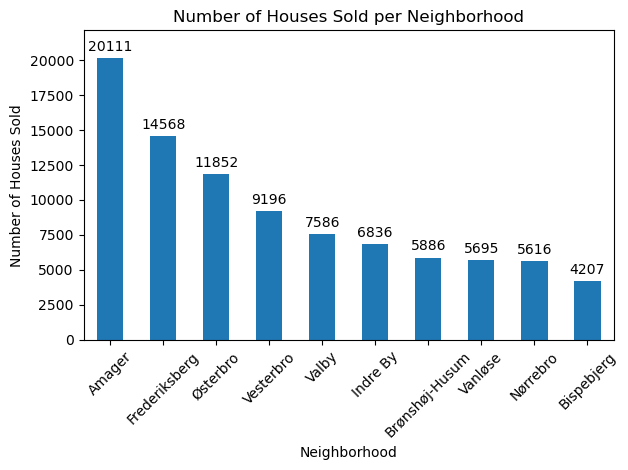

In [3]:
ax = df['neighborhood'].value_counts().plot(kind='bar')
ax.bar_label(ax.containers[0], padding=3)
plt.title('Number of Houses Sold per Neighborhood')
plt.xlabel('Neighborhood')
plt.ylabel('Number of Houses Sold')
plt.ylim(0, df['neighborhood'].value_counts().max() * 1.1)
plt.xticks(rotation=45)
plt.tight_layout()

In [4]:
df.groupby('neighborhood')['purchase_price'].agg(['mean', 'median', 'std'])

,mean,median,std
neighborhood,,,
Amager,3.274996e+06,2895000.0,2.067358e+06
Bispebjerg,2.536727e+06,2150000.0,1.626489e+06
Brønshøj-Husum,2.814610e+06,2400000.0,1.808526e+06
Frederiksberg,3.793048e+06,3300000.0,2.483333e+06
Indre By,4.280457e+06,3700000.0,2.803818e+06
Nørrebro,2.743367e+06,2469000.0,1.647398e+06
Valby,3.051307e+06,2660000.0,2.030047e+06
Vanløse,2.810252e+06,2330000.0,1.887941e+06
Vesterbro,3.956808e+06,3642085.5,2.271774e+06


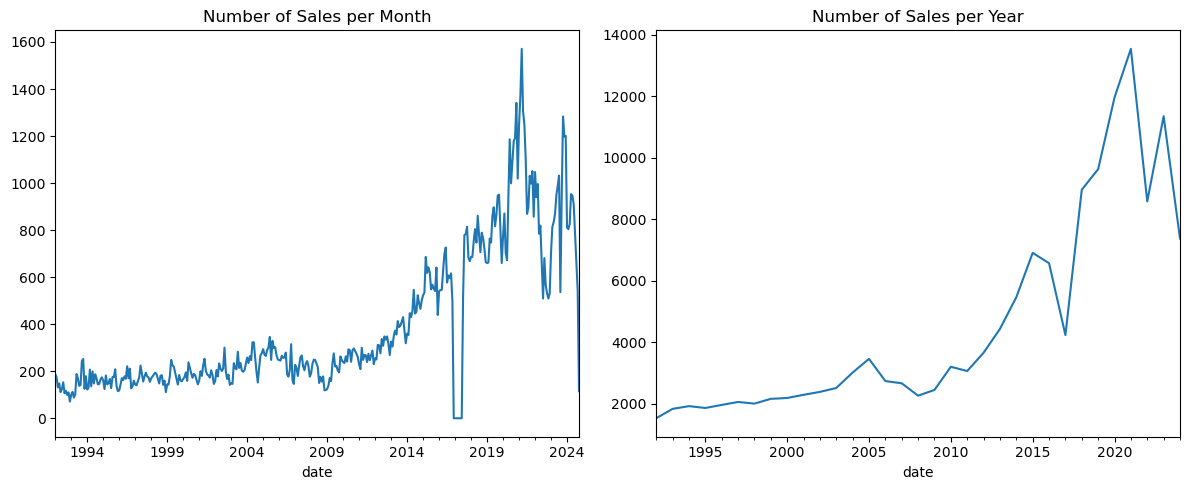

In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))

ts = df.set_index('date').resample('D').size()  # Daily counts of sales

# By month
ts_month = ts.resample('MS').sum()  # MS = month start
ts_month.plot(ax=axes[0])
axes[0].set_title('Number of Sales per Month')

# By year
ts_year = ts.resample('YS').sum()   # YS = year start
ts_year.plot(ax=axes[1])
axes[1].set_title('Number of Sales per Year')

plt.tight_layout()
plt.show()

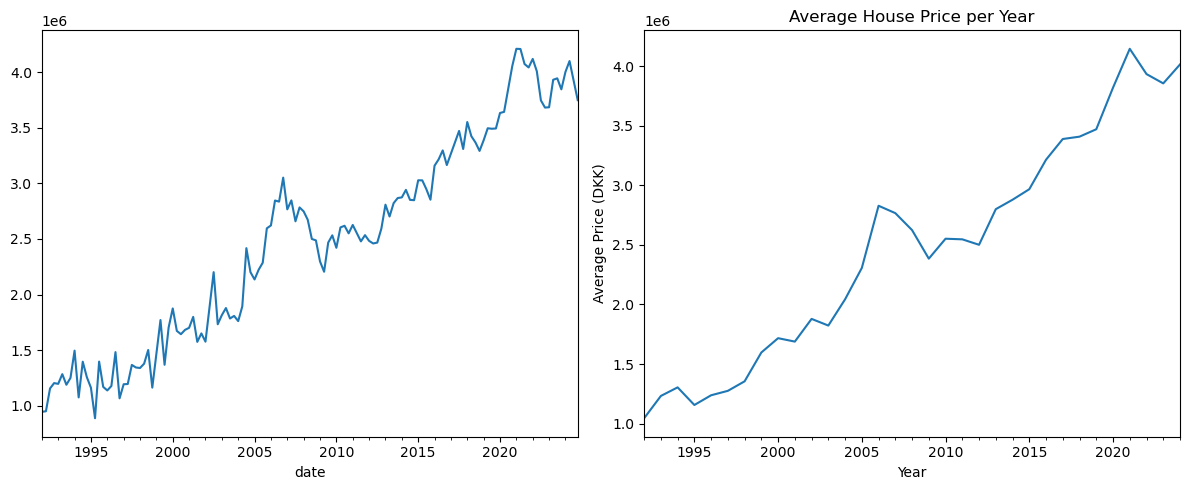

In [6]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(12, 5))
# Average house price per quarter
avg_price_quarter = df.groupby(df['date'].dt.to_period('Q'))['purchase_price'].mean()
avg_price_quarter.plot(ax=axes[0])
plt.title('Average House Price per Quarter')
plt.xlabel('Quarter')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()



avg_price_year = df.groupby(df['date'].dt.to_period('Y'))['purchase_price'].mean()
avg_price_year.plot(ax=axes[1])
plt.title('Average House Price per Year')
plt.xlabel('Year')
plt.ylabel('Average Price (DKK)')
plt.tight_layout()
plt.show()

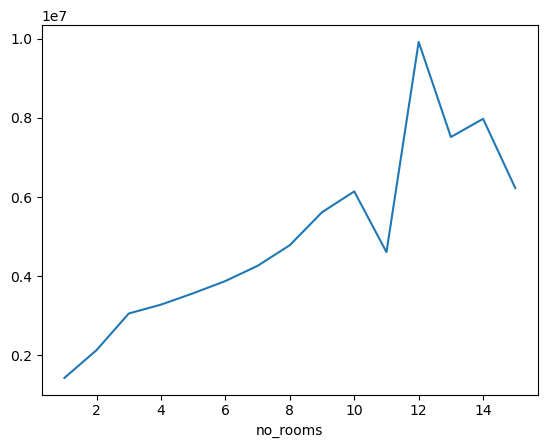

In [7]:
df.groupby('no_rooms')['purchase_price'].mean().plot();

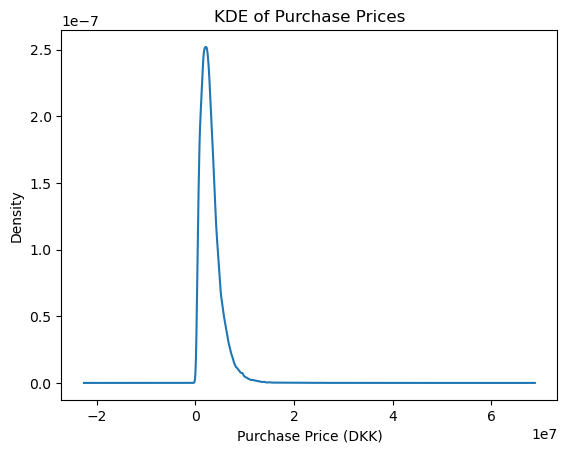

In [8]:
# KDE plot for purchase_price in 2024
df['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

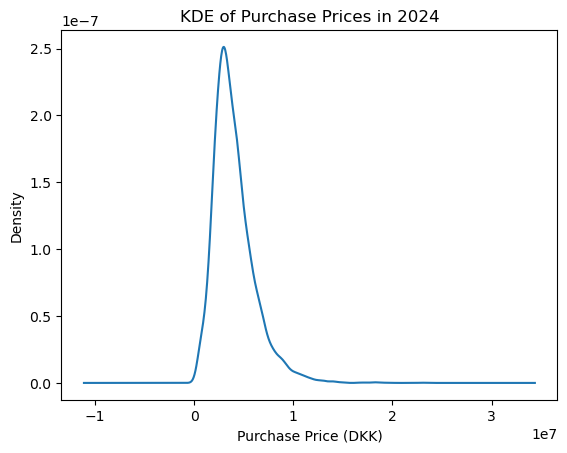

In [9]:
# KDE plot for purchase_price in 2024
df[df['date'] >= '2024-01-01']['purchase_price'].plot(kind='kde')
plt.title('KDE of Purchase Prices in 2024')
plt.xlabel('Purchase Price (DKK)')
plt.ylabel('Density')
plt.show()

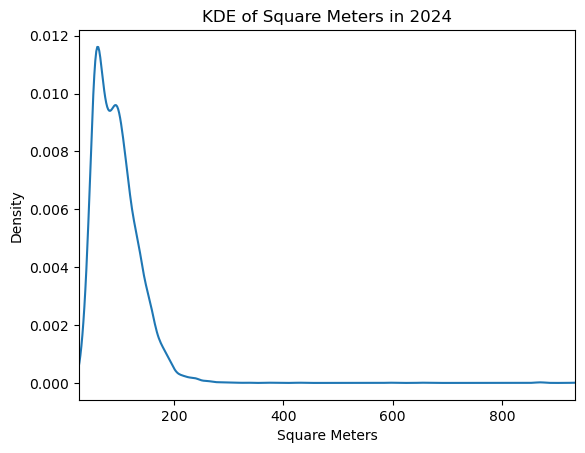

In [10]:
sqm_2024 = df[df['date'] >= '2024-01-01']['sqm']
lower, upper = sqm_2024.quantile([0, 1])
sqm_2024.plot(kind='kde')
plt.title('KDE of Square Meters in 2024')
plt.xlabel('Square Meters')
plt.ylabel('Density')
plt.xlim(lower, upper)
plt.show()

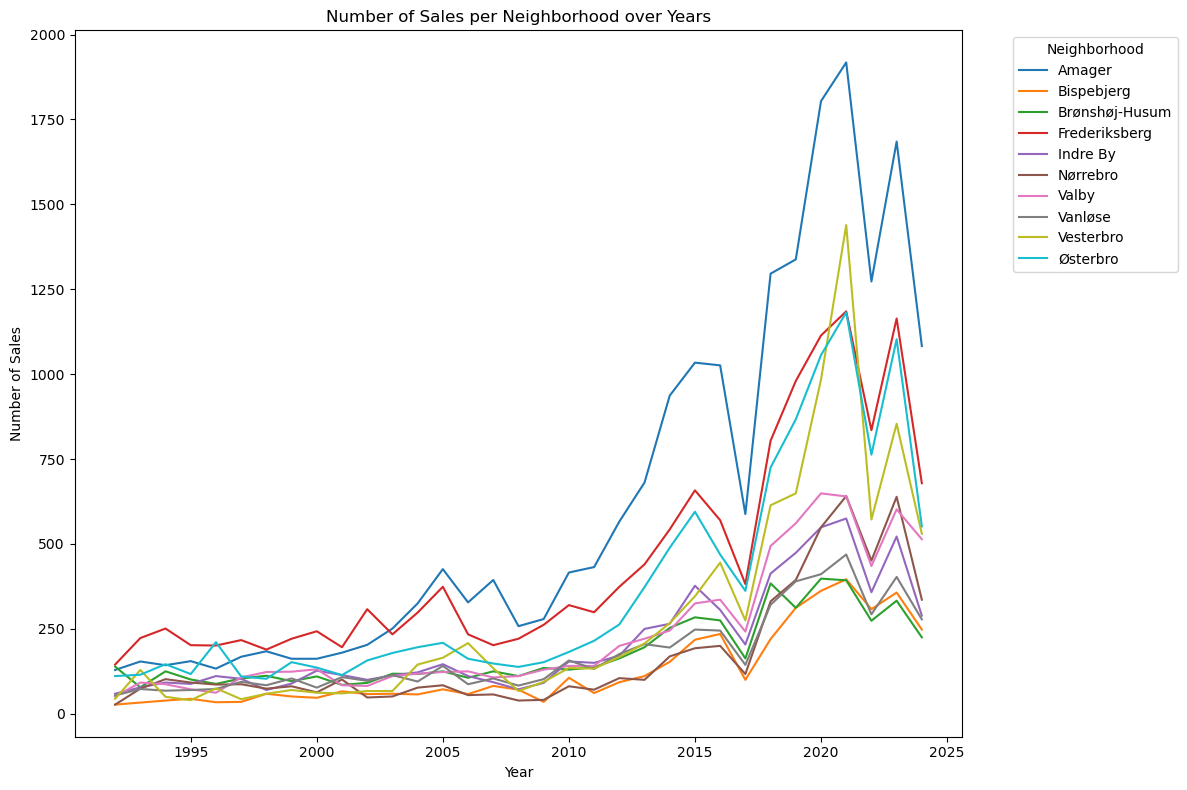

In [11]:
# Plot number of sales per neighborhood over the years
import matplotlib.pyplot as plt

# Group by year and neighborhood, count the number of sales
sales_per_year_neigh = df.groupby([df['date'].dt.year, 'neighborhood']).size().unstack()

# Plot as line chart
sales_per_year_neigh.plot(kind='line', figsize=(12, 8))
plt.title('Number of Sales per Neighborhood over Years')
plt.xlabel('Year')
plt.ylabel('Number of Sales')
plt.legend(title='Neighborhood', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# ============================================================
# 1) Paths
# Run from inside: mbml-cph-housing
# ============================================================
BASE = Path.cwd()

FILES = {
    "KKBEF2": BASE / "data" / "2026417213036619584456KKBEF2.xlsx",
    "KKLEDIG6": BASE / "data" / "2026417213155619584456KKLEDIG6.xlsx",
    "KKIND3": BASE / "data" / "202641721357619584456KKIND3.xlsx",
    "KKHUS1": BASE / "data" / "2026417214930619584456KKHUS1.xlsx",
    "KKFR2026": BASE / "data" / "2026417215628619584456KKFR2026.xlsx",
}

# ============================================================
# 2) File-specific layout
# These are based on the uploaded files you showed.
# ============================================================
CONFIG = {
    "KKBEF2": {
        "sheet_name": "KKBEF2",
        "header_row": 2,   # row with years
        "data_start_row": 3,
        "dim_names": ["ancestry", "age_group", "sex", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKLEDIG6": {
        "sheet_name": "KKLEDIG6",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["education", "unemployment_degree", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKIND3": {
        "sheet_name": "KKIND3",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["income_type", "sex", "unit", "district"],
        "time_name": "year",
        "value_name": "value",
    },
    "KKHUS1": {
        "sheet_name": "KKHUS1",
        "header_row": 2,   # row with quarter labels like 1998Q1
        "data_start_row": 3,
        "dim_names": ["household_size", "children_in_household", "household_type", "district"],
        "time_name": "quarter",
        "value_name": "value",
    },
    "KKFR2026": {
        "sheet_name": "KKFR2026",
        "header_row": 2,
        "data_start_row": 3,
        "dim_names": ["sex", "district", "age"],
        "time_name": "year",
        "value_name": "value",
    },
}

# ============================================================
# 3) Helpers
# ============================================================
def clean_text(x):
    """Standardize cell text while preserving real missing values."""
    if pd.isna(x):
        return np.nan
    x = str(x).strip()
    if x in {"", "nan", "None", "NA", "N/A"}:
        return np.nan
    x = re.sub(r"\s+", " ", x)
    return x

def clean_district_name(x):
    """Optional cleanup for district labels."""
    if pd.isna(x):
        return x
    x = str(x).strip()
    x = re.sub(r"^District\s*-\s*", "", x)
    return x

def parse_quarter_to_period(q):
    """
    Convert strings like 1998Q1 to pandas Period('1998Q1', freq='Q').
    If parsing fails, return original value.
    """
    if pd.isna(q):
        return np.nan
    q = str(q).strip()
    m = re.fullmatch(r"(\d{4})Q([1-4])", q)
    if m:
        year, quarter = m.groups()
        return pd.Period(f"{year}Q{quarter}", freq="Q")
    return q

def load_crosstab_excel(path, sheet_name, header_row, data_start_row, dim_names, time_name, value_name):
    """
    Read a Statistikbanken-style Excel cross table and reshape it to tidy long format.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Clean all cells lightly
    raw = raw.applymap(clean_text)

    n_dims = len(dim_names)

    # Extract time labels from header row
    time_labels = raw.iloc[header_row, n_dims:].tolist()

    # Keep only rows that contain at least one non-missing value somewhere
    data = raw.iloc[data_start_row:, :].copy()
    data = data.dropna(how="all").reset_index(drop=True)

    # Rename columns
    data.columns = dim_names + time_labels

    # Forward-fill the dimension columns only
    data[dim_names] = data[dim_names].ffill()

    # Melt to long format
    tidy = data.melt(
        id_vars=dim_names,
        var_name=time_name,
        value_name=value_name
    )

    # Remove missing values in the measure column
    tidy[value_name] = pd.to_numeric(tidy[value_name], errors="coerce")
    tidy = tidy.dropna(subset=[value_name]).reset_index(drop=True)

    # Clean dimension values
    for col in dim_names:
        tidy[col] = tidy[col].apply(clean_text)

    # District cleanup
    if "district" in tidy.columns:
        tidy["district"] = tidy["district"].apply(clean_district_name)

    # Convert time column
    if time_name == "year":
        tidy[time_name] = pd.to_numeric(tidy[time_name], errors="coerce").astype("Int64")
    elif time_name == "quarter":
        tidy[time_name] = tidy[time_name].apply(parse_quarter_to_period)

    # Final sort
    sort_cols = [c for c in dim_names + [time_name] if c in tidy.columns]
    tidy = tidy.sort_values(sort_cols).reset_index(drop=True)

    return tidy

# ============================================================
# 4) Load all files into tidy dataframes
# ============================================================
data = {}
summary = []

for name, path in FILES.items():
    cfg = CONFIG[name]

    if not path.exists():
        raise FileNotFoundError(f"File not found: {path}")

    df = load_crosstab_excel(
        path=path,
        sheet_name=cfg["sheet_name"],
        header_row=cfg["header_row"],
        data_start_row=cfg["data_start_row"],
        dim_names=cfg["dim_names"],
        time_name=cfg["time_name"],
        value_name=cfg["value_name"],
    )

    data[name] = df

    summary.append({
        "dataset": name,
        "rows": len(df),
        "columns": len(df.columns),
        "time_column": cfg["time_name"],
        "min_time": str(df[cfg["time_name"]].min()) if len(df) else None,
        "max_time": str(df[cfg["time_name"]].max()) if len(df) else None,
    })

# ============================================================
# 5) Create direct dataframe variables
# ============================================================
KKBEF2 = data["KKBEF2"]
KKLEDIG6 = data["KKLEDIG6"]
KKIND3 = data["KKIND3"]
KKHUS1 = data["KKHUS1"]
KKFR2026 = data["KKFR2026"]

# ============================================================
# 6) Print overview
# ============================================================
summary_df = pd.DataFrame(summary)
print("Tidy datasets loaded:")
print(summary_df)

print("\nKKBEF2 sample:")
print(KKBEF2.head())

print("\nKKLEDIG6 sample:")
print(KKLEDIG6.head())

print("\nKKIND3 sample:")
print(KKIND3.head())

print("\nKKHUS1 sample:")
print(KKHUS1.head())

print("\nKKFR2026 sample:")
print(KKFR2026.head())

# ============================================================
# 7) Optional: save cleaned versions
# ============================================================
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

KKBEF2.to_csv(output_dir / "KKBEF2_tidy.csv", index=False)
KKLEDIG6.to_csv(output_dir / "KKLEDIG6_tidy.csv", index=False)
KKIND3.to_csv(output_dir / "KKIND3_tidy.csv", index=False)
KKHUS1.to_csv(output_dir / "KKHUS1_tidy.csv", index=False)
KKFR2026.to_csv(output_dir / "KKFR2026_tidy.csv", index=False)

print(f"\nCleaned CSV files saved to: {output_dir}")

C:\Users\david\AppData\Local\Temp\ipykernel_20916\4205628439.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
C:\Users\david\AppData\Local\Temp\ipykernel_20916\4205628439.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
C:\Users\david\AppData\Local\Temp\ipykernel_20916\4205628439.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
C:\Users\david\AppData\Local\Temp\ipykernel_20916\4205628439.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)
C:\Users\david\AppData\Local\Temp\ipykernel_20916\4205628439.py:109: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  raw = raw.applymap(clean_text)


Tidy datasets loaded:
    dataset   rows  columns time_column min_time max_time
0    KKBEF2  23194        6        year     1986     2025
1  KKLEDIG6   4800        5        year     2008     2023
2    KKIND3  11400        6        year     1987     2024
3    KKHUS1  76800        6     quarter   1998Q1   2024Q4
4  KKFR2026  70000        5        year     2026     2060

KKBEF2 sample:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amager Vest  1987   
2  Descendants of non-western origin  0-10 years  Men  Amager Vest  1988   
3  Descendants of non-western origin  0-10 years  Men  Amager Vest  1989   
4  Descendants of non-western origin  0-10 years  Men  Amager Vest  1990   

   value  
0  109.0  
1  136.0  
2  163.0  
3  168.0  
4  189.0  

KKLEDIG6 sample:
                           education unemployment_degree     district  ye

In [3]:
import pandas as pd

# Assumes these already exist from your load script:
# data, KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026

datasets = {
    "KKBEF2": KKBEF2,
    "KKLEDIG6": KKLEDIG6,
    "KKIND3": KKIND3,
    "KKHUS1": KKHUS1,
    "KKFR2026": KKFR2026,
}

for name, df in datasets.items():
    print("=" * 80)
    print(f"{name}")
    print("=" * 80)

    print("\nShape:")
    print(df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nDtypes:")
    print(df.dtypes)

    print("\nMissing values per column:")
    print(df.isna().sum())

    print("\nExact duplicate rows:")
    print(df.duplicated().sum())

    # Identify value and time columns
    value_col = "value"
    time_col = "quarter" if "quarter" in df.columns else "year"

    # Dimension columns = everything except time and value
    dim_cols = [c for c in df.columns if c not in [time_col, value_col]]

    print("\nDimension columns:")
    print(dim_cols)

    print("\nNumber of duplicated keys (same dimensions + same time):")
    print(df.duplicated(subset=dim_cols + [time_col]).sum())

    print("\nValue summary:")
    print(df[value_col].describe())

    print("\nNegative values count:")
    print((df[value_col] < 0).sum())

    print("\nSample rows:")
    print(df.head(10))

    print("\nUnique values per dimension column (first 15 shown):")
    for col in dim_cols:
        uniques = df[col].dropna().unique()
        print(f"\n- {col}: {len(uniques)} unique")
        print(list(uniques[:15]))

    print("\nTime column summary:")
    print("Type:", df[time_col].dtype)
    print("Min:", df[time_col].min())
    print("Max:", df[time_col].max())

    # Check if every key-time combination appears only once
    group_sizes = df.groupby(dim_cols + [time_col]).size()
    bad_groups = group_sizes[group_sizes > 1]

    print("\nNumber of key-time combinations appearing more than once:")
    print(len(bad_groups))

    if len(bad_groups) > 0:
        print("\nFirst 10 duplicated key-time combinations:")
        print(bad_groups.head(10))

    print("\n")

KKBEF2

Shape:
(23194, 6)

Columns:
['ancestry', 'age_group', 'sex', 'district', 'year', 'value']

Dtypes:
ancestry      object
age_group     object
sex           object
district      object
year           Int64
value        float64
dtype: object

Missing values per column:
ancestry     0
age_group    0
sex          0
district     0
year         0
value        0
dtype: int64

Exact duplicate rows:
0

Dimension columns:
['ancestry', 'age_group', 'sex', 'district']

Number of duplicated keys (same dimensions + same time):
0

Value summary:
count    23194.000000
mean       906.619298
std       1484.900458
min          0.000000
25%         49.000000
50%        219.000000
75%       1096.000000
max      11420.000000
Name: value, dtype: float64

Negative values count:
0

Sample rows:
                            ancestry   age_group  sex     district  year  \
0  Descendants of non-western origin  0-10 years  Men  Amager Vest  1986   
1  Descendants of non-western origin  0-10 years  Men  Amage

In [4]:
for name, df in datasets.items():
    time_col = "quarter" if "quarter" in df.columns else "year"
    print(name, "->", df[time_col].isna().sum(), "missing time values")

KKBEF2 -> 0 missing time values
KKLEDIG6 -> 0 missing time values
KKIND3 -> 0 missing time values
KKHUS1 -> 0 missing time values
KKFR2026 -> 0 missing time values


In [5]:
import pandas as pd
import numpy as np
from pathlib import Path

# ============================================================
# Assumes these already exist from your tidy import script:
# KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026
# ============================================================

# ============================================================
# 1) Helpers
# ============================================================
def safe_slug(x):
    x = str(x).strip().lower()
    x = x.replace("&", "and")
    x = x.replace("%", "pct")
    x = x.replace("/", "_")
    x = x.replace("-", "_")
    x = x.replace(",", "")
    x = x.replace(".", "")
    x = x.replace("(", "")
    x = x.replace(")", "")
    x = x.replace(":", "")
    x = x.replace("'", "")
    x = x.replace('"', "")
    x = "_".join(x.split())
    while "__" in x:
        x = x.replace("__", "_")
    return x

def flatten_columns(columns):
    flat = []
    for col in columns:
        if isinstance(col, tuple):
            parts = [safe_slug(c) for c in col if c not in [None, "", "nan"]]
            flat.append("_".join(parts))
        else:
            flat.append(safe_slug(col))
    return flat

def make_wide(df, id_cols, category_cols, value_col, prefix):
    """
    Converts tidy long df into district-year wide format.
    """
    out = df.copy()

    # Ensure clean types
    out = out.dropna(subset=id_cols + category_cols + [value_col]).copy()

    # Pivot to wide
    wide = out.pivot_table(
        index=id_cols,
        columns=category_cols,
        values=value_col,
        aggfunc="sum"
    ).reset_index()

    # Flatten multiindex columns
    wide.columns = id_cols + [
        f"{prefix}_" + "_".join([safe_slug(x) for x in col]) if isinstance(col, tuple) else f"{prefix}_{safe_slug(col)}"
        for col in wide.columns[len(id_cols):]
    ]

    return wide

# ============================================================
# 2) Standardize district/year formats
# ============================================================
KKBEF2 = KKBEF2.copy()
KKLEDIG6 = KKLEDIG6.copy()
KKIND3 = KKIND3.copy()
KKHUS1 = KKHUS1.copy()
KKFR2026 = KKFR2026.copy()

for df in [KKBEF2, KKLEDIG6, KKIND3, KKHUS1, KKFR2026]:
    if "district" in df.columns:
        df["district"] = df["district"].astype(str).str.strip()

if "year" in KKBEF2.columns:
    KKBEF2["year"] = pd.to_numeric(KKBEF2["year"], errors="coerce").astype("Int64")
if "year" in KKLEDIG6.columns:
    KKLEDIG6["year"] = pd.to_numeric(KKLEDIG6["year"], errors="coerce").astype("Int64")
if "year" in KKIND3.columns:
    KKIND3["year"] = pd.to_numeric(KKIND3["year"], errors="coerce").astype("Int64")
if "year" in KKFR2026.columns:
    KKFR2026["year"] = pd.to_numeric(KKFR2026["year"], errors="coerce").astype("Int64")

# Convert quarter -> year for housing
if "quarter" in KKHUS1.columns:
    if str(KKHUS1["quarter"].dtype) == "period[Q-DEC]":
        KKHUS1["year"] = KKHUS1["quarter"].dt.year.astype("Int64")
    else:
        KKHUS1["year"] = (
            KKHUS1["quarter"]
            .astype(str)
            .str.extract(r"(\d{4})", expand=False)
            .pipe(pd.to_numeric, errors="coerce")
            .astype("Int64")
        )

# ============================================================
# 3) Aggregate quarterly housing to annual mean
# ============================================================
KKHUS1_yearly = (
    KKHUS1
    .groupby(["household_size", "children_in_household", "household_type", "district", "year"], as_index=False)["value"]
    .mean()
)

# ============================================================
# 4) Pivot each dataset to district-year wide format
# ============================================================
KKBEF2_wide = make_wide(
    df=KKBEF2,
    id_cols=["district", "year"],
    category_cols=["ancestry", "age_group", "sex"],
    value_col="value",
    prefix="pop"
)

KKLEDIG6_wide = make_wide(
    df=KKLEDIG6,
    id_cols=["district", "year"],
    category_cols=["education", "unemployment_degree"],
    value_col="value",
    prefix="unemp"
)

KKIND3_wide = make_wide(
    df=KKIND3,
    id_cols=["district", "year"],
    category_cols=["income_type", "sex", "unit"],
    value_col="value",
    prefix="income"
)

KKHUS1_wide = make_wide(
    df=KKHUS1_yearly,
    id_cols=["district", "year"],
    category_cols=["household_size", "children_in_household", "household_type"],
    value_col="value",
    prefix="housing"
)

KKFR2026_wide = make_wide(
    df=KKFR2026,
    id_cols=["district", "year"],
    category_cols=["sex", "age"],
    value_col="value",
    prefix="proj_pop"
)

# ============================================================
# 5) Merge historical datasets
# Use outer merge to keep all district-year combinations
# ============================================================
historical_panel = KKBEF2_wide.merge(
    KKLEDIG6_wide, on=["district", "year"], how="outer"
).merge(
    KKIND3_wide, on=["district", "year"], how="outer"
).merge(
    KKHUS1_wide, on=["district", "year"], how="outer"
)

historical_panel = historical_panel.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 6) Keep future population projections separate
# Since only KKFR2026 covers future years
# ============================================================
future_population_panel = KKFR2026_wide.sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 7) Optional combined panel
# This appends future projections to historical data structure
# Most future columns will be NaN except projected population
# ============================================================
combined_panel = historical_panel.merge(
    future_population_panel, on=["district", "year"], how="outer"
).sort_values(["district", "year"]).reset_index(drop=True)

# ============================================================
# 8) Diagnostics
# ============================================================
print("=" * 80)
print("HISTORICAL PANEL")
print("=" * 80)
print("Shape:", historical_panel.shape)
print("Years:", historical_panel["year"].min(), "to", historical_panel["year"].max())
print("Districts:", historical_panel["district"].nunique())
print("Duplicated district-year rows:", historical_panel.duplicated(subset=["district", "year"]).sum())
print(historical_panel.head())

print("\n" + "=" * 80)
print("FUTURE POPULATION PANEL")
print("=" * 80)
print("Shape:", future_population_panel.shape)
print("Years:", future_population_panel["year"].min(), "to", future_population_panel["year"].max())
print("Districts:", future_population_panel["district"].nunique())
print("Duplicated district-year rows:", future_population_panel.duplicated(subset=["district", "year"]).sum())
print(future_population_panel.head())

print("\n" + "=" * 80)
print("COMBINED PANEL")
print("=" * 80)
print("Shape:", combined_panel.shape)
print("Years:", combined_panel["year"].min(), "to", combined_panel["year"].max())
print("Districts:", combined_panel["district"].nunique())
print("Duplicated district-year rows:", combined_panel.duplicated(subset=["district", "year"]).sum())
print(combined_panel.head())

# ============================================================
# 9) Save outputs
# ============================================================
BASE = Path.cwd()
output_dir = BASE / "data" / "cleaned"
output_dir.mkdir(parents=True, exist_ok=True)

historical_panel.to_csv(output_dir / "historical_panel_merged.csv", index=False)
future_population_panel.to_csv(output_dir / "future_population_panel.csv", index=False)
combined_panel.to_csv(output_dir / "combined_panel_with_future_population.csv", index=False)

print(f"\nSaved to: {output_dir}")
print("- historical_panel_merged.csv")
print("- future_population_panel.csv")
print("- combined_panel_with_future_population.csv")

HISTORICAL PANEL
Shape: (400, 212)
Years: 1986 to 2025
Districts: 10
Duplicated district-year rows: 0
      district  year  pop_descendants_of_non_western_origin_0_10_years_men  \
0  Amager Vest  1986                                              109.0      
1  Amager Vest  1987                                              136.0      
2  Amager Vest  1988                                              163.0      
3  Amager Vest  1989                                              168.0      
4  Amager Vest  1990                                              189.0      

   pop_descendants_of_non_western_origin_0_10_years_women  \
0                                              129.0        
1                                              143.0        
2                                              154.0        
3                                              182.0        
4                                              185.0        

   pop_descendants_of_non_western_origin_10_19_years_men  \
0 